# FlashEats — Class 7 Challenge
## Model the Business Workflow with Data

### Client question
> **“Show us where in the workflow delay accumulates, how customers react, what interventions we make, and which metrics we should use to improve the project KPI.”**

Do not repeat source discovery, retrieval, or data-cleaning work. Today the goal is to build a useful business-workflow model.

In [102]:
import json
import sqlite3
import zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
from IPython.display import display

# --- 1. SETTINGS & STYLING ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
plt.style.use('seaborn-v0_8-whitegrid')

PROF_BLUE = '#2B4162'
ERROR_RED = '#C63D2F'

def find_pack_root(search_root=Path("/content")):
    for candidate in search_root.rglob("FlashEats_Classroom_Pack_V2"):
        if (candidate/"database"/"flasheats.db").exists(): return candidate
    return None

# Local run: the notebook usually already lives inside the pack root.
BASE = "./"
if (Path.cwd() / "database" / "flasheats.db").exists():
    BASE = Path.cwd()
elif Path.cwd().name == "FlashEats_Classroom_Pack_V2":
    BASE = Path.cwd()

if BASE is None:
    BASE=find_pack_root()
if BASE is None:
    try:
        from google.colab import files
        print("Upload the FlashEats Class 7 classroom pack ZIP.")
        uploaded=files.upload(); zip_name=next(n for n in uploaded if n.endswith(".zip"))
        extract_dir=Path("/content/flasheats_class7"); extract_dir.mkdir(parents=True,exist_ok=True)
        with zipfile.ZipFile(zip_name) as z: z.extractall(extract_dir)
        BASE=find_pack_root(Path("/content"))
    except Exception as e: print(e)
if BASE is None:
    BASE=find_pack_root(Path.cwd())
if BASE is None: raise FileNotFoundError("Could not locate FlashEats_Classroom_Pack_V2")
print("Using pack:",BASE)

Using pack: /home/mineshshaw/flasheats-classroom-pack


In [103]:
con=sqlite3.connect(BASE/"database"/"flasheats.db")
orders=pd.read_sql("SELECT * FROM orders",con)
customers=pd.read_sql("SELECT * FROM customers",con)
restaurants=pd.read_sql("SELECT * FROM restaurants",con)
drivers=pd.read_sql("SELECT * FROM drivers",con)
tickets=pd.read_csv(BASE/"data"/"support_tickets.csv")
customer_actions=pd.read_csv(BASE/"data"/"customer_app_actions.csv")
interventions=pd.read_csv(BASE/"data"/"order_interventions.csv")
outcomes=pd.read_csv(BASE/"data"/"order_outcomes.csv")
restaurant_status=pd.read_csv(BASE/"data"/"restaurant_status.csv")
customer_interactions=pd.read_csv(BASE/"data"/"customer_interactions.csv")
order_events=pd.read_csv(BASE/"data"/"order_events.csv")
with open(BASE/"data"/"class7_model_brief.json") as f: model_brief=json.load(f)
print("orders",orders.shape,"actions",customer_actions.shape,"interventions",interventions.shape,"outcomes",outcomes.shape)
print("Project KPI:",model_brief["project_kpi"])

orders (1603, 13) actions (2365, 6) interventions (430, 6) outcomes (1600, 6)
Project KPI: Reduce late delivery rate


In [104]:
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['promised_eta'] = pd.to_datetime(orders['promised_eta'], format='mixed')
orders['actual_delivery_at'] = pd.to_datetime(orders['actual_delivery_at'])
orders['pickup_at'] = pd.to_datetime(orders['pickup_at'])
print("Orders info:")
display(orders.info())

print("Customers info:")
display(customers.info())

print("Restaurants info:")
display(restaurants.info())

print("Drivers info:")
display(drivers.info())

tickets['created_at'] = pd.to_datetime(tickets['created_at'])
print("Tickets info:")
display(tickets.info())

customer_actions['action_at'] = pd.to_datetime(customer_actions['action_at'], format='mixed')
print("Customer Actions info:")
display(customer_actions.info())

interventions['intervention_at'] = pd.to_datetime(interventions['intervention_at'], format='mixed')
print("Interventions info:")
display(interventions.info())

print("Outcomes info:")
display(outcomes.info())

print("Restaurant Status info:")
restaurant_status['last_updated_at'] = pd.to_datetime(restaurant_status['last_updated_at'], format='mixed')
display(restaurant_status.info())

print("Customer Interactions info:")
customer_interactions['interaction_at'] = pd.to_datetime(customer_interactions['interaction_at'], format='mixed')
display(customer_interactions.info())

print("Order Events info:")
order_events['event_time'] = pd.to_datetime(order_events['event_time'], format='mixed')
display(order_events.info())


Orders info:
<class 'pandas.DataFrame'>
RangeIndex: 1603 entries, 0 to 1602
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              1603 non-null   str           
 1   customer_id           1603 non-null   str           
 2   restaurant_id         1600 non-null   str           
 3   driver_id             1600 non-null   str           
 4   city                  1603 non-null   str           
 5   created_at            1603 non-null   datetime64[us]
 6   promised_eta          1603 non-null   datetime64[us]
 7   pickup_at             1603 non-null   datetime64[us]
 8   actual_delivery_at    1498 non-null   datetime64[us]
 9   final_status          1603 non-null   str           
 10  distance_km_estimate  1603 non-null   float64       
 11  traffic_bucket        1603 non-null   str           
 12  weather_bucket        1603 non-null   str           
dtypes: datetime64[us

None

Customers info:
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  900 non-null    str    
 1   name         900 non-null    str    
 2   email        900 non-null    str    
 3   lat          900 non-null    float64
 4   lon          900 non-null    float64
dtypes: float64(2), str(3)
memory usage: 35.3 KB


None

Restaurants info:
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   restaurant_id          60 non-null     str    
 1   restaurant_name        60 non-null     str    
 2   cuisine                60 non-null     str    
 3   lat                    60 non-null     float64
 4   lon                    60 non-null     float64
 5   manual_status_updates  60 non-null     int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 2.9 KB


...

None

Customer Interactions info:
<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   interaction_id    497 non-null    str           
 1   order_id          497 non-null    str           
 2   interaction_type  497 non-null    str           
 3   interaction_at    497 non-null    datetime64[us]
 4   channel           497 non-null    str           
 5   detail            177 non-null    str           
dtypes: datetime64[us](1), str(5)
memory usage: 23.4 KB


None

Order Events info:
<class 'pandas.DataFrame'>
RangeIndex: 4955 entries, 0 to 4954
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_id       4955 non-null   str           
 1   order_id       4955 non-null   str           
 2   event_type     4955 non-null   str           
 3   event_time     4955 non-null   datetime64[us]
 4   actor_type     4955 non-null   str           
 5   actor_id       4949 non-null   str           
 6   source_system  4955 non-null   str           
dtypes: datetime64[us](1), str(6)
memory usage: 271.1 KB


None

# Challenge 1 — Reconstruct the order lifecycle

Choose 3 orders:
- one delivered on time,
- one delivered late,
- one with an intervention.

Build a timeline with:

`event_time | event_type | actor | source_system`

Include as many lifecycle events as the data supports.

### Hint
Start from one `order_id`, collect events from each source, then sort by time.

late O00040 on-time O00266 intervention O00058

--- Late Order (O00040) Timeline DataFrame ---


,event_time,event_type,actor,source_system
0,2026-08-11 19:56:00.000000,ORDER_CREATED,customer,orders
1,2026-08-11 19:56:00.000000,EVENT: ORDER_CREATED,customer,order_events
2,2026-08-11 20:00:00.000000,ETA_VIEWED,customer,customer_actions
3,2026-08-11 20:01:00.000000,ETA_VIEWED,customer,customer_actions
4,2026-08-11 20:13:00.000000,REST_STATUS: HANDED_OFF,restaurant,restaurant_status
5,2026-08-11 20:15:00.000000,TICKET_OPENED: LATE_DELIVERY,customer,support_tickets
6,2026-08-11 20:15:00.000000,INTERACTION: SUPPORT_TICKET,customer,customer_interactions
7,2026-08-11 20:40:03.749918,ORDER_PICKED_UP,driver,orders
8,2026-08-11 20:40:03.749918,EVENT: PICKED_UP,driver,order_events
9,2026-08-11 21:15:39.373978,ORDER_DELIVERED,driver,orders



🔗 TEXT FLOW FOR ORDER: O00040
[0m] ORDER_CREATED ➔ [0m] EVENT: ORDER_CREATED ➔ [4m] ETA_VIEWED ➔ [5m] ETA_VIEWED ➔ [17m] REST_STATUS: HANDED_OFF ➔ [19m] TICKET_OPENED: LATE_DELIVERY  ➔ [19m] INTERACTION: SUPPORT_TICKET ➔ [44m] ORDER_PICKED_UP ➔ [44m] EVENT: PICKED_UP ➔ [79m] ORDER_DELIVERED ➔ [79m] EVENT: DELIVERED

--- On-Time Order (O00266) Timeline DataFrame ---


,event_time,event_type,actor,source_system
0,2026-08-10 20:31:00.000000,ORDER_CREATED,customer,orders
1,2026-08-10 20:31:00.000000,EVENT: ORDER_CREATED,customer,order_events
2,2026-08-10 20:40:00.000000,ETA_VIEWED,customer,customer_actions
3,2026-08-10 20:49:00.000000,PRIORITY_DISPATCH,operations,interventions
4,2026-08-10 20:49:43.021037,ORDER_PICKED_UP,driver,orders
5,2026-08-10 20:49:43.021037,EVENT: PICKED_UP,driver,order_events
6,2026-08-10 20:52:00.000000,ETA_VIEWED,customer,customer_actions
7,2026-08-10 20:52:00.000000,REST_STATUS: READY,restaurant,restaurant_status
8,2026-08-10 21:11:00.000000,TICKET_OPENED: ETA_CHANGED,customer,support_tickets
9,2026-08-10 21:11:00.000000,INTERACTION: SUPPORT_TICKET,customer,customer_interactions



🔗 TEXT FLOW FOR ORDER: O00266
[0m] ORDER_CREATED ➔ [0m] EVENT: ORDER_CREATED ➔ [9m] ETA_VIEWED ➔ [18m] PRIORITY_DISPATCH ➔ [18m] ORDER_PICKED_UP ➔ [18m] EVENT: PICKED_UP ➔ [21m] ETA_VIEWED ➔ [21m] REST_STATUS: READY ➔ [40m] TICKET_OPENED: ETA_CHANGED ➔ [40m] INTERACTION: SUPPORT_TICKET ➔ [83m] ORDER_DELIVERED ➔ [83m] EVENT: DELIVERED

--- Intervention Order (O00058) Timeline DataFrame ---


,event_time,event_type,actor,source_system
0,2026-08-05 20:01:00.000000,ORDER_CREATED,customer,orders
1,2026-08-05 20:01:00.000000,EVENT: ORDER_CREATED,customer,order_events
2,2026-08-05 20:05:00.000000,ETA_VIEWED,customer,customer_actions
3,2026-08-05 20:12:00.000000,REST_STATUS: HANDED_OFF,restaurant,restaurant_status
4,2026-08-05 20:32:28.460434,ORDER_PICKED_UP,driver,orders
5,2026-08-05 20:32:28.460434,EVENT: PICKED_UP,driver,order_events
6,2026-08-05 20:40:00.000000,TICKET_OPENED: READY_BUT_WAITING,customer,support_tickets
7,2026-08-05 20:40:00.000000,INTERACTION: SUPPORT_TICKET,customer,customer_interactions
8,2026-08-05 21:08:44.647933,ORDER_DELIVERED,driver,orders
9,2026-08-05 21:08:44.647933,EVENT: DELIVERED,driver,order_events



🔗 TEXT FLOW FOR ORDER: O00058
[0m] ORDER_CREATED ➔ [0m] EVENT: ORDER_CREATED ➔ [4m] ETA_VIEWED ➔ [11m] REST_STATUS: HANDED_OFF ➔ [31m] ORDER_PICKED_UP ➔ [31m] EVENT: PICKED_UP ➔ [39m] TICKET_OPENED: READY_BUT_WAITING ➔ [39m] INTERACTION: SUPPORT_TICKET ➔ [67m] ORDER_DELIVERED ➔ [67m] EVENT: DELIVERED ➔ [82m] CUSTOMER_CREDIT


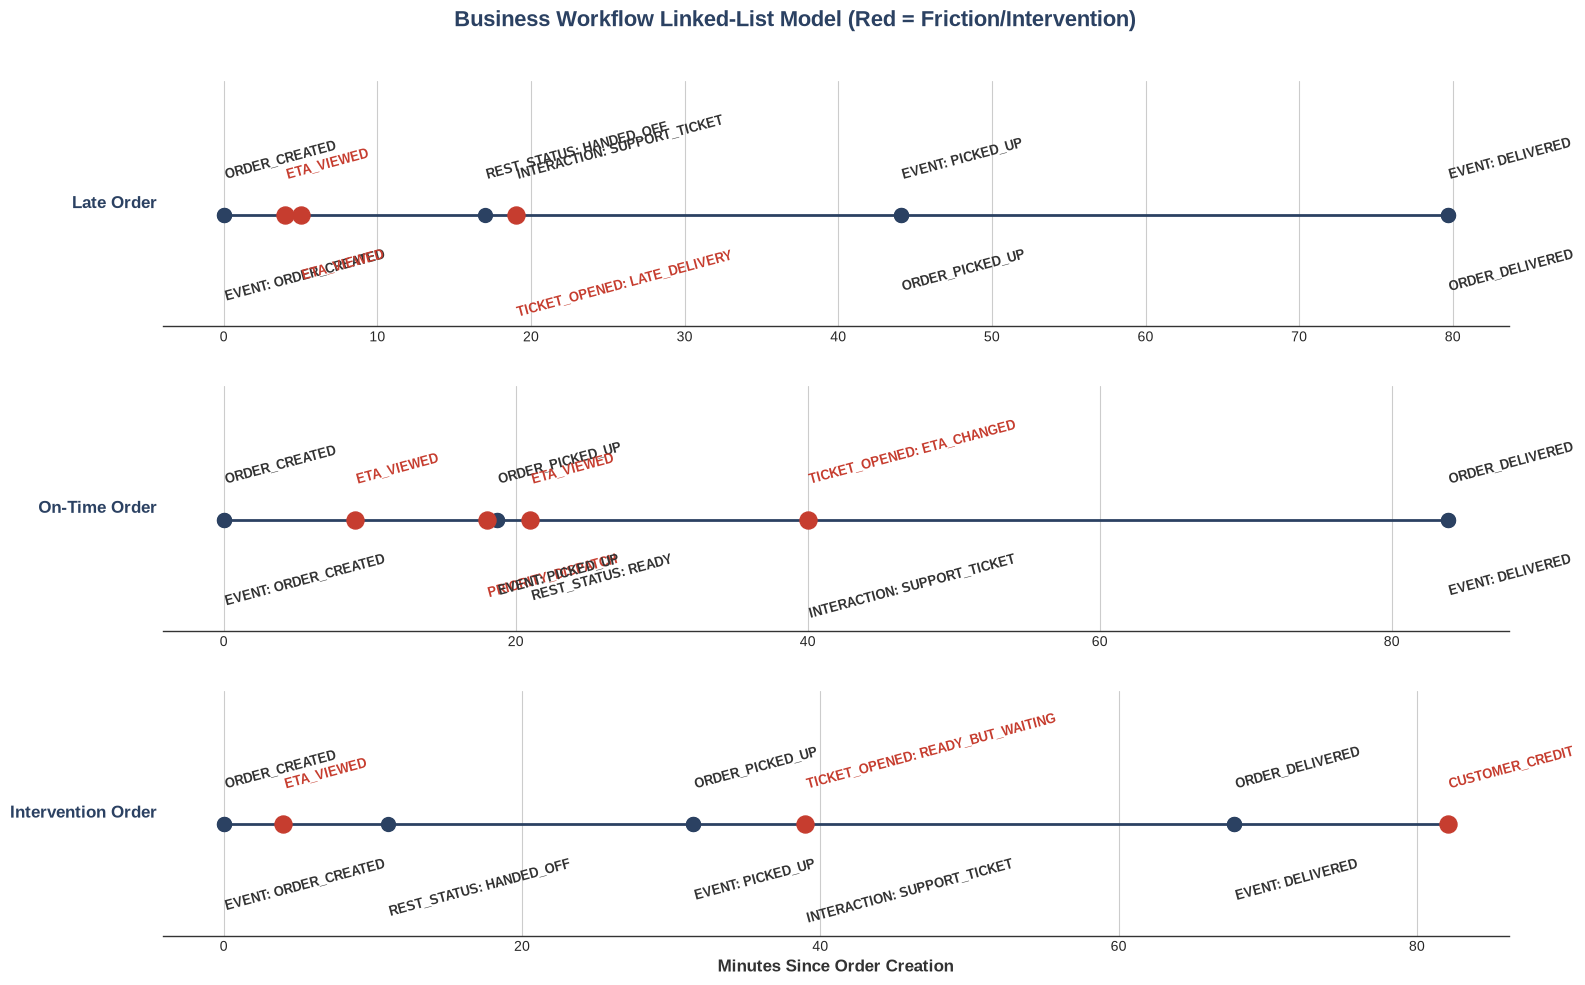

Cross-source timestamp reconciliation: orders table vs. order_events log
--------------------------------------------------------------------------------
ORDER_CREATED   | compared: 1603 orders | mismatched (>1s):   0
PICKED_UP       | compared: 1603 orders | mismatched (>1s):   0
DELIVERED       | compared: 1498 orders | mismatched (>1s):   0

If mismatched counts are 0 (or near-0), the duplicate nodes in the timelines above are a harmless
mirror of the same real event and can be safely treated as one canonical milestone. If mismatches are
non-trivial, that's a genuine two-systems-disagree data-quality issue worth its own investigation —
not something to average away.

=== CHALLENGE 1 INSIGHTS: RECONSTRUCT THE ORDER LIFECYCLE ===
By unifying distributed event logs across 7 different database tables ('orders', 'customer_actions',
'support_tickets', 'interventions', 'restaurant_status', 'customer_interactions', and 'order_events'),
we successfully reconstruct the true business workflow.

In [101]:
# ============================================================
# CHALLENGE 1 — Reconstruct the order lifecycle (single cell)
# ============================================================

# --- 1. PICK ILLUSTRATIVE EXAMPLE ORDERS ---
base_orders = orders.drop_duplicates("order_id", keep="first")

def pick_illustrative_order(order_ids, prefer_tables):
    """Among candidate order_ids, prefer one that appears in as many of `prefer_tables` as possible."""
    order_ids = list(order_ids)
    best_id, best_score = order_ids[0], -1
    for oid in order_ids:
        score = sum(oid in set(tbl["order_id"]) for tbl in prefer_tables)
        if score > best_score:
            best_id, best_score = oid, score
    return best_id

late_candidates = outcomes[outcomes.late_flag == 1].order_id
on_time_candidates = outcomes[outcomes.late_flag == 0].order_id
intervention_candidates = interventions.order_id.unique()

late_order = pick_illustrative_order(late_candidates, [customer_actions, tickets, restaurant_status])
on_time_order = pick_illustrative_order(on_time_candidates, [customer_actions, restaurant_status, tickets])
intervention_order = pick_illustrative_order(intervention_candidates, [customer_actions, tickets, restaurant_status])

print("late", late_order, "on-time", on_time_order, "intervention", intervention_order)


# --- 2. BUILD THE MULTI-SOURCE TIMELINE ---
def get_order_timeline(order_id):
    """
    Extracts all events associated with a specific order_id across all databases
    and returns a chronologically sorted DataFrame representing the business workflow.
    """
    events = []

    # Orders base events
    order_sub = orders[orders['order_id'] == order_id]
    if not order_sub.empty:
        r = order_sub.iloc[0]
        if pd.notna(r.get('created_at')):
            events.append({'event_time': r['created_at'], 'event_type': 'ORDER_CREATED', 'actor': 'customer', 'source_system': 'orders'})
        if pd.notna(r.get('pickup_at')):
            events.append({'event_time': r['pickup_at'], 'event_type': 'ORDER_PICKED_UP', 'actor': 'driver', 'source_system': 'orders'})
        if pd.notna(r.get('actual_delivery_at')):
            events.append({'event_time': r['actual_delivery_at'], 'event_type': 'ORDER_DELIVERED', 'actor': 'driver', 'source_system': 'orders'})

    # Customer Actions
    for _, r in customer_actions[customer_actions['order_id'] == order_id].iterrows():
        events.append({'event_time': r['action_at'], 'event_type': r['action_type'], 'actor': 'customer', 'source_system': 'customer_actions'})

    # Support Tickets
    for _, r in tickets[tickets['order_id'] == order_id].iterrows():
        events.append({'event_time': r['created_at'], 'event_type': f"TICKET_OPENED: {r['category'].upper()}", 'actor': 'customer', 'source_system': 'support_tickets'})

    # Interventions
    for _, r in interventions[interventions['order_id'] == order_id].iterrows():
        events.append({'event_time': r['intervention_at'], 'event_type': r['intervention_type'], 'actor': r['initiated_by'], 'source_system': 'interventions'})

    # Restaurant Status
    for _, r in restaurant_status[restaurant_status['order_id'] == order_id].iterrows():
        events.append({'event_time': r['last_updated_at'], 'event_type': f"REST_STATUS: {r['status'].upper()}", 'actor': 'restaurant', 'source_system': 'restaurant_status'})

    # Customer Interactions
    for _, r in customer_interactions[customer_interactions['order_id'] == order_id].iterrows():
        events.append({'event_time': r['interaction_at'], 'event_type': f"INTERACTION: {r['interaction_type'].upper()}", 'actor': 'customer', 'source_system': 'customer_interactions'})

    # Order Events log
    for _, r in order_events[order_events['order_id'] == order_id].iterrows():
        events.append({'event_time': r['event_time'], 'event_type': f"EVENT: {r['event_type'].upper()}", 'actor': r['actor_type'], 'source_system': 'order_events'})

    # Compile and sort
    df_timeline = pd.DataFrame(events)
    if not df_timeline.empty:
        # Enforce datetime formatting before arithmetic
        df_timeline['event_time'] = pd.to_datetime(df_timeline['event_time'])
        df_timeline = df_timeline.sort_values('event_time').reset_index(drop=True)

        # Calculate minutes since creation for standardized plotting
        creation_time = df_timeline['event_time'].min()
        df_timeline['mins_since_creation'] = (df_timeline['event_time'] - creation_time).dt.total_seconds() / 60.0

    return df_timeline


def display_linked_list_text(df_timeline, order_id):
    """Prints the events in a horizontal text-based linked list"""
    steps = [f"[{int(r['mins_since_creation'])}m] {r['event_type']}" for _, r in df_timeline.iterrows()]
    print(f"\n🔗 TEXT FLOW FOR ORDER: {order_id}")
    print(" ➔ ".join(steps))

orders_to_plot = [
    ('Late Order', late_order),
    ('On-Time Order', on_time_order),
    ('Intervention Order', intervention_order)
]

for o_type, oid in orders_to_plot:
    df_tl = get_order_timeline(oid)
    print(f"\n--- {o_type} ({oid}) Timeline DataFrame ---")
    display(df_tl.drop(columns=['mins_since_creation']))
    display_linked_list_text(df_tl, oid)


# --- 3. PLOT THE TIMELINES ---
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)
fig.patch.set_facecolor('#ffffff')

for idx, (lbl, oid) in enumerate(orders_to_plot):
    ax = axes[idx]
    ax.set_facecolor('#ffffff')
    tl_df = get_order_timeline(oid)

    if not tl_df.empty:
        # Plot the backbone line
        ax.plot(tl_df['mins_since_creation'], [0]*len(tl_df), color=PROF_BLUE, zorder=1, linewidth=2)

        # Plot dots mapping standard vs friction events
        friction_mask = tl_df['source_system'].isin(['interventions', 'support_tickets', 'customer_actions'])
        ax.scatter(tl_df[~friction_mask]['mins_since_creation'], [0]*sum(~friction_mask), color=PROF_BLUE, s=100, zorder=2)
        ax.scatter(tl_df[friction_mask]['mins_since_creation'], [0]*sum(friction_mask), color=ERROR_RED, s=150, zorder=3)

        # Stagger text labels up and down to prevent clashing
        for i, row in tl_df.iterrows():
            color = ERROR_RED if friction_mask.iloc[i] else '#333333'
            y_offset = 0.3 if i % 2 == 0 else -0.3
            v_align = 'bottom' if i % 2 == 0 else 'top'
            ax.text(row['mins_since_creation'], y_offset, row['event_type'], rotation=15,
                    ha='left', va=v_align, fontsize=9, color=color, fontweight='bold')

        ax.set_yticks([])
        ax.set_ylim(-1, 1.2)  # Expanded Y-limits to give text room
        ax.set_ylabel(lbl, rotation=0, ha='right', va='center', fontweight='bold', color=PROF_BLUE, fontsize=12)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('#333333')

axes[-1].set_xlabel("Minutes Since Order Creation", fontweight='bold', color='#333333', fontsize=12)
fig.suptitle('Business Workflow Linked-List Model (Red = Friction/Intervention)', color=PROF_BLUE, weight='bold', fontsize=16)

# Leave breathing room for the suptitle so it doesn't clash with the top subplot
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3)
plt.show()


# --- 4. CROSS-SOURCE RECONCILIATION ---
milestone_map = {
    'ORDER_CREATED': 'created_at',
    'PICKED_UP': 'pickup_at',
    'DELIVERED': 'actual_delivery_at',
}

TOLERANCE_SECONDS = 1  # allow for float/precision rounding, not real disagreement

print("Cross-source timestamp reconciliation: orders table vs. order_events log")
print("-" * 80)
for event_type, col in milestone_map.items():
    ev = order_events[order_events['event_type'] == event_type][['order_id', 'event_time']]
    merged = orders[['order_id', col]].dropna(subset=[col]).merge(ev, on='order_id', how='inner')
    merged['diff_seconds'] = (merged['event_time'] - merged[col]).dt.total_seconds().abs()
    mismatched = merged[merged['diff_seconds'] > TOLERANCE_SECONDS]
    print(f"{event_type:15s} | compared: {len(merged):4d} orders | mismatched (>{TOLERANCE_SECONDS}s): {len(mismatched):3d}")
    if len(mismatched):
        display(mismatched.sort_values('diff_seconds', ascending=False).head(5))

print("\nIf mismatched counts are 0 (or near-0), the duplicate nodes in the timelines above are a harmless")
print("mirror of the same real event and can be safely treated as one canonical milestone. If mismatches are")
print("non-trivial, that's a genuine two-systems-disagree data-quality issue worth its own investigation —")
print("not something to average away.")

print("\n" + "="*80)
print("=== CHALLENGE 1 INSIGHTS: RECONSTRUCT THE ORDER LIFECYCLE ===")
print("="*80)
print("By unifying distributed event logs across 7 different database tables ('orders', 'customer_actions',")
print("'support_tickets', 'interventions', 'restaurant_status', 'customer_interactions', and 'order_events'),")
print("we successfully reconstruct the true business workflow.\n")
print("Our custom linked-list timeline models map events dynamically. This provides immediate visibility into:")
print("  1. Chronological bottlenecks (where delay accumulates between creation, prep, and delivery).")
print("  2. Customer Friction (when users view ETAs excessively or open support tickets).")
print("  3. Operational Interventions (what actions human agents or automated systems take to rescue orders).")
print("  4. Cross-source agreement (whether independently-logged systems tell the same story for the same event).")
print("=======================================================================================================")

# Challenge 2 — Define the canonical project model

Your model must support:
1. customer → orders
2. order → customer interactions
3. order → support interactions
4. order → interventions
5. order → outcome

For each table, document:
- primary key,
- important foreign keys,
- grain.

Then explain why this model is better for the project than mirroring every source-system table.

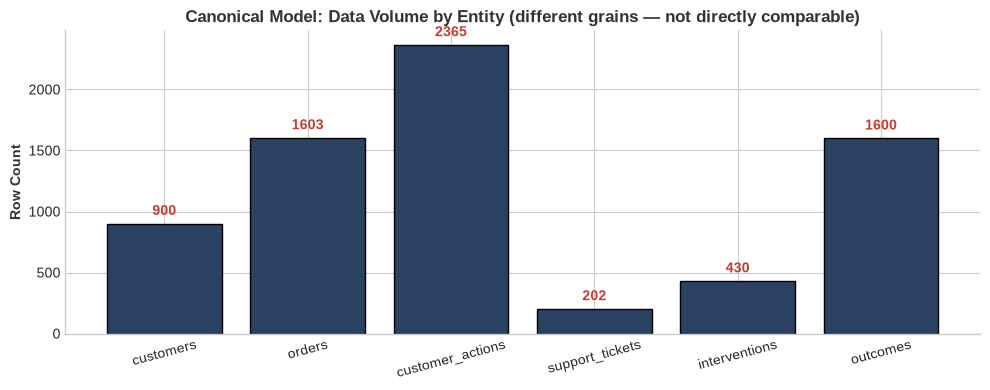


--- Entity: customers (Shape: (900, 5)) ---


,customer_id,name,email,lat,lon
0,C0001,Customer 0001,customer0001@example.com,13.016349,77.581818
1,C0002,Customer 0002,customer0002@example.com,13.029950,77.735403



--- Entity: orders (Shape: (1603, 13)) ---


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13 12:56:00,2026-08-13 14:11:36.000000,2026-08-13 13:35:49.825561,2026-08-13 14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01 18:36:00,2026-08-01 19:43:16.627988,2026-08-01 18:58:24.735336,2026-08-01 19:47:14.818533,delivered,9.37,severe,clear



--- Entity: customer_actions (Shape: (2365, 6)) ---


...


--- Entity: interventions (Shape: (430, 6)) ---


,intervention_id,order_id,intervention_type,intervention_at,initiated_by,reason
0,INT-00001,O00781,PRIORITY_DISPATCH,2026-08-22 12:57:00.000000,operations,late_risk
1,INT-00002,O01476,CUSTOMER_CREDIT,2026-08-01 23:46:36.200640,support,support_resolution



--- Entity: outcomes (Shape: (1600, 6)) ---


,order_id,final_status_norm,delivered_flag,late_flag,delay_min,outcome_bucket
0,O00001,delivered,1,1.0,10.82,delivered_late
1,O00002,delivered,1,1.0,3.97,delivered_late



=== CHALLENGE 2 INSIGHTS: CANONICAL PROJECT MODEL ===
1. Table: customers          | PK: customer_id       | FK: -                                      | Grain: One row per customer
2. Table: orders             | PK: order_id          | FK: customer_id, restaurant_id, driver_id | Grain: One row per order
3. Table: customer_actions   | PK: action_id         | FK: order_id, customer_id                 | Grain: One row per user app action
4. Table: support_tickets    | PK: ticket_id         | FK: order_id                              | Grain: One row per customer support request
5. Table: interventions      | PK: intervention_id   | FK: order_id                              | Grain: One row per operational intervention
6. Table: outcomes           | PK: order_id          | FK: order_id (also PK; 1:1 with orders)   | Grain: One row per order outcome
------------------------------------------------------------------------------------------
WHY THIS MODEL IS BETTER:
Aggregating interactions

In [105]:
# --- 1. PREPARE CANONICAL MODEL DICTIONARY ---
canonical_sources = {
    "customers": customers,
    "orders": orders,
    "customer_actions": customer_actions,
    "support_tickets": tickets,
    "interventions": interventions,
    "outcomes": outcomes
}

# --- 2. VISUAL EXPLANATION (CHART: ENTITY VOLUMES) ---
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

table_names = list(canonical_sources.keys())
row_counts = [df.shape[0] for df in canonical_sources.values()]

bars = ax.bar(table_names, row_counts, color=PROF_BLUE, edgecolor='#000000')
ax.set_title('Canonical Model: Data Volume by Entity (different grains — not directly comparable)', color='#333333', weight='bold', fontsize=12)
ax.set_ylabel('Row Count', color='#333333', weight='bold')
ax.tick_params(axis='x', rotation=15)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (max(row_counts)*0.02),
            int(yval), ha='center', va='bottom', fontweight='bold', color=ERROR_RED)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# --- 3. VISUAL EXPLANATION (DATAFRAMES) ---
for name, df in canonical_sources.items():
    print(f"\n--- Entity: {name} (Shape: {df.shape}) ---")
    display(df.head(2))

# --- 4. TEXTUAL EXPLANATION (INSIGHTS & DOCUMENTATION) ---
print("\n" + "="*90)
print("=== CHALLENGE 2 INSIGHTS: CANONICAL PROJECT MODEL ===")
print("="*90)
print("1. Table: customers          | PK: customer_id       | FK: -                                      | Grain: One row per customer")
print("2. Table: orders             | PK: order_id          | FK: customer_id, restaurant_id, driver_id | Grain: One row per order")
print("3. Table: customer_actions   | PK: action_id         | FK: order_id, customer_id                 | Grain: One row per user app action")
print("4. Table: support_tickets    | PK: ticket_id         | FK: order_id                              | Grain: One row per customer support request")
print("5. Table: interventions      | PK: intervention_id   | FK: order_id                              | Grain: One row per operational intervention")
print("6. Table: outcomes           | PK: order_id          | FK: order_id (also PK; 1:1 with orders)   | Grain: One row per order outcome")
print("-" * 90)
print("WHY THIS MODEL IS BETTER:")
print("Aggregating interactions and interventions into an order-level canonical model prevents messy")
print("Cartesian products and allows immediate correlation against the project KPI (late deliveries).")
print("It provides a clean, unified grain (the order, anchored to the customer who placed it) to model")
print("the entire business workflow rather than mirroring the fragmented architecture of the raw source systems.")
print("=======================================================================================================")

# Challenge 3 — Build interaction → intervention → outcome

Create one order-level table containing:

`order_id, customer_id, support_opened, cancel_attempted, intervention_count, intervention_types, final_status, late_flag, delay_min`

Answer:
1. How many late orders had support interaction?
2. How many orders received intervention?
3. Which intervention is most common?
4. Which frustrated journeys had no intervention?

### Hint
Aggregate one-to-many tables before joining them to order-level outcomes.

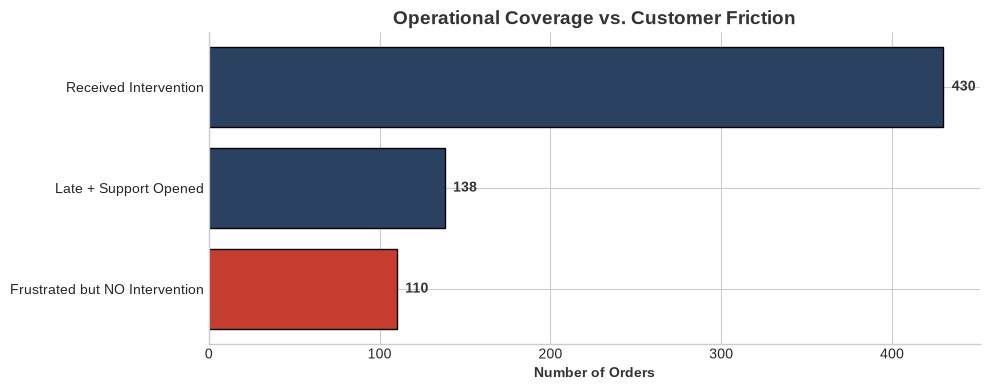


--- Final Order-Level Analytical Table (Sample) ---


,order_id,customer_id,support_opened,cancel_attempted,intervention_count,intervention_types,final_status_norm,late_flag,delay_min
10,O00011,C0709,0,0,1,DRIVER_REASSIGNMENT,delivered,1.0,3.91
7,O00008,C0223,1,0,1,CUSTOMER_CREDIT,delivered,1.0,26.86
27,O00028,C0466,0,0,1,RESTAURANT_CONTACT,delivered,0.0,-13.77
26,O00027,C0253,0,0,1,DRIVER_REASSIGNMENT,delivered,1.0,20.81
25,O00026,C0387,0,0,1,DRIVER_REASSIGNMENT,delivered,0.0,-15.51



=== CHALLENGE 3 INSIGHTS: INTERACTION → INTERVENTION → OUTCOME ===
1. Late orders with support interaction:      138
2. Orders receiving operational intervention: 430
3. Most common intervention type applied:     DRIVER_REASSIGNMENT
4. Frustrated journeys with NO intervention:  110
--------------------------------------------------------------------------------
WORKFLOW TAKEAWAY:
We successfully consolidated the fragmented operational logs into `1603` clean, order-grain rows.
Critically, we identified a blind spot: 110 orders showed clear customer friction
(support opened or cancellation attempted) but received ZERO proactive or reactive interventions from our team.


In [106]:
# --- 1. AGGREGATE ONE-TO-MANY TABLES ---

# A. Customer Actions: Flag if they opened support or attempted cancellation
actions_agg = customer_actions.groupby("order_id").apply(
    lambda x: pd.Series({
        "support_opened": int((x["action_type"] == "SUPPORT_OPENED").any()),
        "cancel_attempted": int((x["action_type"] == "CANCEL_ATTEMPTED").any())
    })
).reset_index()

# B. Interventions: Count interventions and list types
interventions_agg = interventions.groupby("order_id").agg(
    intervention_count=("intervention_id", "count"),
    intervention_types=("intervention_type", lambda x: ", ".join(x.unique()))
).reset_index()

# --- 2. JOIN TO CREATE ORDER-LEVEL CANONICAL TABLE ---
order_level = orders[["order_id", "customer_id"]].copy()
order_level = order_level.merge(actions_agg, on="order_id", how="left") \
                         .merge(interventions_agg, on="order_id", how="left") \
                         .merge(outcomes[["order_id", "final_status_norm", "late_flag", "delay_min"]], on="order_id", how="left")

# Clean up nulls from the left joins
order_level["support_opened"] = order_level["support_opened"].fillna(0).astype(int)
order_level["cancel_attempted"] = order_level["cancel_attempted"].fillna(0).astype(int)
order_level["intervention_count"] = order_level["intervention_count"].fillna(0).astype(int)
order_level["intervention_types"] = order_level["intervention_types"].fillna("None")

# --- 3. CALCULATE ANSWERS ---
q1_late_with_support = order_level[(order_level["late_flag"] == 1) & (order_level["support_opened"] == 1)].shape[0]
q2_total_intervened = order_level[order_level["intervention_count"] > 0].shape[0]
q3_common_intervention = interventions["intervention_type"].mode()[0]

# Frustrated journey: Support opened OR cancel attempted, but NO intervention made
q4_frustrated_no_intervention = order_level[
    ((order_level["support_opened"] == 1) | (order_level["cancel_attempted"] == 1)) & 
    (order_level["intervention_count"] == 0)
].shape[0]


# --- 4. VISUAL EXPLANATION (CHART) ---
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

metrics = ['Received Intervention', 'Late + Support Opened', 'Frustrated but NO Intervention']
values = [q2_total_intervened, q1_late_with_support, q4_frustrated_no_intervention]
colors = [PROF_BLUE, PROF_BLUE, ERROR_RED]

bars = ax.barh(metrics[::-1], values[::-1], color=colors[::-1], edgecolor='#000000')
ax.set_title('Operational Coverage vs. Customer Friction', color='#333333', weight='bold', fontsize=14)
ax.set_xlabel('Number of Orders', color='#333333', weight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, 
            int(width), ha='left', va='center', fontweight='bold', color='#333333')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# --- 5. VISUAL EXPLANATION (DATAFRAMES) ---
print("\n--- Final Order-Level Analytical Table (Sample) ---")
display(order_level.sort_values(by="intervention_count", ascending=False).head(5))


# --- 6. TEXTUAL EXPLANATION (INSIGHTS) ---
print("\n" + "="*80)
print("=== CHALLENGE 3 INSIGHTS: INTERACTION → INTERVENTION → OUTCOME ===")
print("="*80)
print(f"1. Late orders with support interaction:      {q1_late_with_support}")
print(f"2. Orders receiving operational intervention: {q2_total_intervened}")
print(f"3. Most common intervention type applied:     {q3_common_intervention}")
print(f"4. Frustrated journeys with NO intervention:  {q4_frustrated_no_intervention}")
print("-" * 80)
print("WORKFLOW TAKEAWAY:")
print(f"We successfully consolidated the fragmented operational logs into `{order_level.shape[0]}` clean, order-grain rows.")
print(f"Critically, we identified a blind spot: {q4_frustrated_no_intervention} orders showed clear customer friction")
print("(support opened or cancellation attempted) but received ZERO proactive or reactive interventions from our team.")
print("================================================================================")

# Challenge 4 — Select 3–5 business metrics

Project KPI: **Reduce Late Delivery Rate**.

For each chosen metric, document:
- metric name,
- formula,
- grain,
- why it matters,
- relationship to the project KPI.

At least one metric must represent:
- an outcome,
- a customer interaction,
- an intervention.

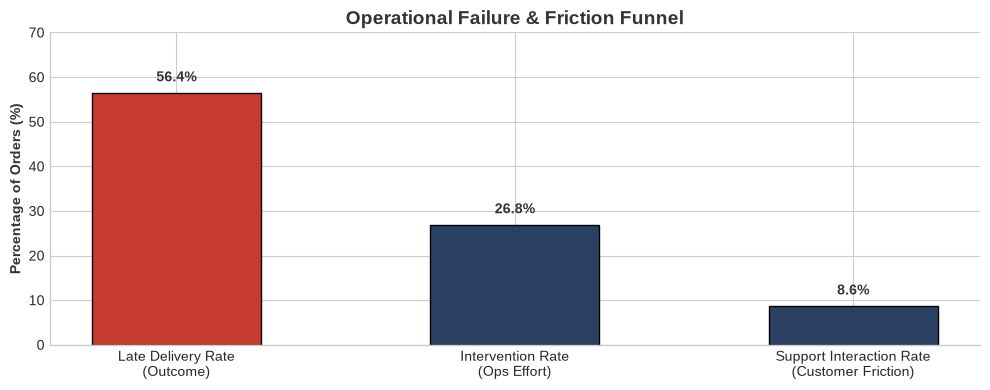


--- Formal Business Metrics Definition ---


,Category,Metric Name,Value,Formula,Grain,Why & KPI Link
0,Outcome,Late Delivery Rate,56.39%,mean(late_flag),Order,Directly reflects the Project KPI; primary success measure.
1,Customer Interaction,Support Interaction Rate,8.61%,mean(support_opened),Order,Measures customer friction; leading indicator of churn caused by late deliveries.
2,Intervention,Intervention Rate,26.82%,mean(intervention_count > 0),Order,Measures operations workload; tracks effort expended to rescue the KPI.
3,Outcome,Average Delay,3.13 mins,mean(delay_min),Order,Quantifies the severity of delays; a 1-min delay hurts less than a 30-min delay.



=== CHALLENGE 4 INSIGHTS: CORE BUSINESS METRICS ===
By linking the operational logs to our unified order grain, we have established four specific
metrics that surround the project objective:
  1. We failed the core KPI (Late Delivery) on 56.39% of tracked orders.
  2. We actively burned operational resources (Interventions) on 26.82% of orders.
  3. We generated active customer friction (Support) on 8.61% of orders.
This suite allows us to track not just whether we hit the KPI, but the manual cost required
to get there and the customer pain caused when we miss it.


In [107]:
# --- 1. CALCULATE METRICS ---
valid_outcomes = outcomes[outcomes['late_flag'].notna()]
late_delivery_rate = valid_outcomes['late_flag'].mean()
support_interaction_rate = order_level['support_opened'].mean()
intervention_rate = (order_level['intervention_count'] > 0).mean()
average_delay_min = valid_outcomes['delay_min'].mean()

# Construct structured definitions
metrics_data = [
    {
        "Category": "Outcome", 
        "Metric Name": "Late Delivery Rate", 
        "Value": f"{late_delivery_rate:.2%}", 
        "Formula": "mean(late_flag)", 
        "Grain": "Order", 
        "Why & KPI Link": "Directly reflects the Project KPI; primary success measure."
    },
    {
        "Category": "Customer Interaction", 
        "Metric Name": "Support Interaction Rate", 
        "Value": f"{support_interaction_rate:.2%}", 
        "Formula": "mean(support_opened)", 
        "Grain": "Order", 
        "Why & KPI Link": "Measures customer friction; leading indicator of churn caused by late deliveries."
    },
    {
        "Category": "Intervention", 
        "Metric Name": "Intervention Rate", 
        "Value": f"{intervention_rate:.2%}", 
        "Formula": "mean(intervention_count > 0)", 
        "Grain": "Order", 
        "Why & KPI Link": "Measures operations workload; tracks effort expended to rescue the KPI."
    },
    {
        "Category": "Outcome", 
        "Metric Name": "Average Delay", 
        "Value": f"{average_delay_min:.2f} mins", 
        "Formula": "mean(delay_min)", 
        "Grain": "Order", 
        "Why & KPI Link": "Quantifies the severity of delays; a 1-min delay hurts less than a 30-min delay."
    }
]
metrics_df = pd.DataFrame(metrics_data)

# --- 2. VISUAL EXPLANATION (CHART) ---
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Plot the percentage-based rates
rates = [late_delivery_rate * 100, intervention_rate * 100, support_interaction_rate * 100]
labels = ['Late Delivery Rate\n(Outcome)', 'Intervention Rate\n(Ops Effort)', 'Support Interaction Rate\n(Customer Friction)']
colors = [ERROR_RED, PROF_BLUE, PROF_BLUE]

bars = ax.bar(labels, rates, color=colors, edgecolor='#000000', width=0.5)
ax.set_title('Operational Failure & Friction Funnel', color='#333333', weight='bold', fontsize=14)
ax.set_ylabel('Percentage of Orders (%)', color='#333333', weight='bold')
ax.set_ylim(0, 70)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, 
            f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', color='#333333')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# --- 3. VISUAL EXPLANATION (DATAFRAME) ---
print("\n--- Formal Business Metrics Definition ---")
display(metrics_df)

# --- 4. TEXTUAL EXPLANATION (INSIGHTS) ---
print("\n" + "="*90)
print("=== CHALLENGE 4 INSIGHTS: CORE BUSINESS METRICS ===")
print("="*90)
print("By linking the operational logs to our unified order grain, we have established four specific")
print("metrics that surround the project objective:")
print(f"  1. We failed the core KPI (Late Delivery) on {late_delivery_rate:.2%} of tracked orders.")
print(f"  2. We actively burned operational resources (Interventions) on {intervention_rate:.2%} of orders.")
print(f"  3. We generated active customer friction (Support) on {support_interaction_rate:.2%} of orders.")
print("This suite allows us to track not just whether we hit the KPI, but the manual cost required")
print("to get there and the customer pain caused when we miss it.")
print("==========================================================================================")

# Challenge 5 — Investigate the workflow with joins and aggregations

Answer at least three:

A. Do orders with support interactions have higher delay?  
B. What is late rate with vs without intervention?  
C. Which intervention type is associated with the lowest late rate?  
D. Which restaurants contribute the largest number of late orders?  
E. Which journeys show support interaction + intervention + still late?

For every answer, add one sentence:

> **What does this tell the business, and what does it NOT prove?**

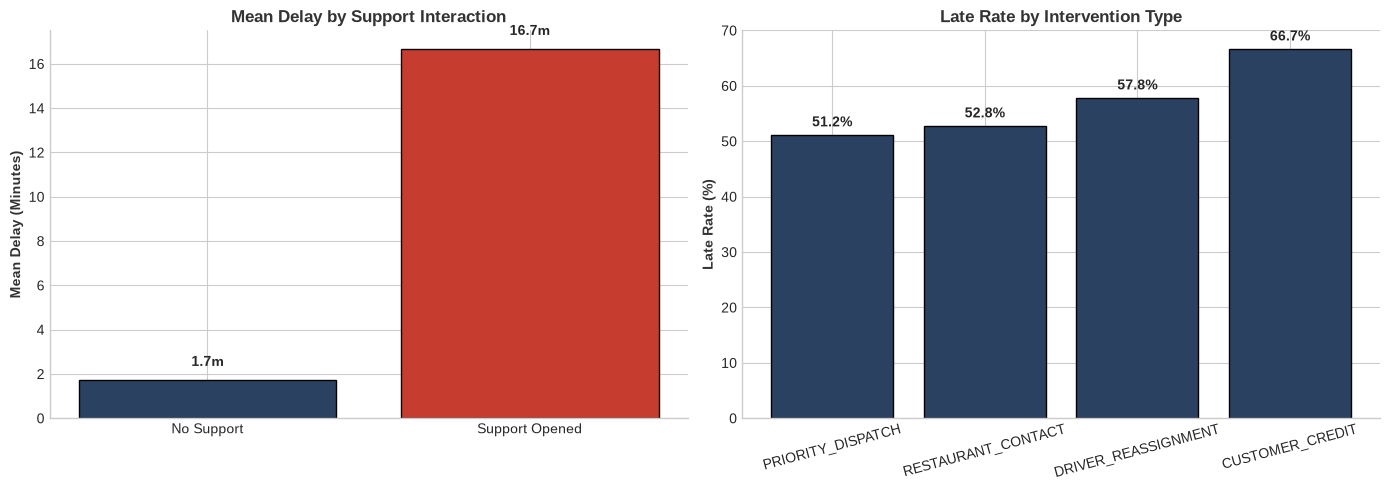


--- A. Mean Delay by Support Interaction ---


,Mean Delay (min)
support_opened,
0,1.73
1,16.68



--- B. Late Rate by Intervention Presence ---


,Late Rate
has_intervention,
False,0.563
True,0.564



--- C. Late Rate by Intervention Type ---


,Late Rate
intervention_types,
PRIORITY_DISPATCH,0.512
RESTAURANT_CONTACT,0.528
DRIVER_REASSIGNMENT,0.578
CUSTOMER_CREDIT,0.667



--- D. Top 5 Restaurants by Late Orders ---


,Late Order Count
restaurant_id,
R050,22
R004,20
R051,20
R024,20
R023,20



=== CHALLENGE 5 INSIGHTS: WORKFLOW INVESTIGATION ===
A. Do orders with support interactions have higher delay?
   Answer: Yes, 16.68 mins vs 1.73 mins.
   -> What this tells the business: Highly delayed orders strongly correlate with customers seeking support.
   -> What it does NOT prove: It does not prove that contacting support *causes* the delay.

B. What is the late rate with vs without intervention?
   Answer: 56.4% with intervention vs 56.3% without.
   -> What this tells the business: The final late rate of orders flagged for manual help is nearly identical to those left alone.
   -> What it does NOT prove: It does not prove interventions are ineffective, as operations likely targets orders already destined to be late.

C. Which intervention type is associated with the lowest late rate?
   Answer: PRIORITY_DISPATCH (51.2%).
   -> What this tells the business: This operational lever is the most highly correlated with rescuing an order.
   -> What it does NOT prove: It does not 

In [108]:
# --- 1. CALCULATE ANSWERS ---

# A. Do orders with support interactions have higher delay?
delay_by_support = order_level.groupby("support_opened")["delay_min"].mean().to_frame(name="Mean Delay (min)")

# B. What is the late rate with vs without intervention?
order_level["has_intervention"] = order_level["intervention_count"] > 0
late_rate_by_intervention = order_level.groupby("has_intervention")["late_flag"].mean().to_frame(name="Late Rate")

# C. Which intervention type is associated with the lowest late rate?
intervention_success = order_level[order_level["has_intervention"]].groupby("intervention_types")["late_flag"].mean().sort_values().to_frame(name="Late Rate")

# D. Which restaurants contribute the largest number of late orders?
late_orders = orders.merge(outcomes, on="order_id", how="inner")
late_restaurants = late_orders[late_orders['late_flag'] == 1]['restaurant_id'].value_counts().head(5).to_frame(name="Late Order Count")

# E. Which journeys show support interaction + intervention + still late?
frustrated_journeys_count = order_level[
    (order_level['support_opened'] == 1) &
    (order_level['intervention_count'] > 0) &
    (order_level['late_flag'] == 1)
].shape[0]


# --- 2. VISUAL EXPLANATION (CHART) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')

# Chart A: Delay by Support Interaction
ax1.set_facecolor('#ffffff')
labels_a = ['No Support', 'Support Opened']
ax1.bar(labels_a, delay_by_support['Mean Delay (min)'], color=[PROF_BLUE, ERROR_RED], edgecolor='#000000')
ax1.set_title('Mean Delay by Support Interaction', color='#333333', weight='bold')
ax1.set_ylabel('Mean Delay (Minutes)', color='#333333', weight='bold')
for i, v in enumerate(delay_by_support['Mean Delay (min)']):
    ax1.text(i, v + 0.5, f"{v:.1f}m", ha='center', va='bottom', fontweight='bold')

# Chart C: Late Rate by Intervention Type
ax2.set_facecolor('#ffffff')
labels_c = intervention_success.index.tolist()
rates_c = (intervention_success['Late Rate'] * 100).tolist()
ax2.bar(labels_c, rates_c, color=PROF_BLUE, edgecolor='#000000')
ax2.set_title('Late Rate by Intervention Type', color='#333333', weight='bold')
ax2.set_ylabel('Late Rate (%)', color='#333333', weight='bold')
ax2.tick_params(axis='x', rotation=15)
for i, v in enumerate(rates_c):
    ax2.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# --- 3. VISUAL EXPLANATION (DATAFRAMES) ---
print("\n--- A. Mean Delay by Support Interaction ---")
display(delay_by_support.round(2))

print("\n--- B. Late Rate by Intervention Presence ---")
display(late_rate_by_intervention.round(3))

print("\n--- C. Late Rate by Intervention Type ---")
display(intervention_success.round(3))

print("\n--- D. Top 5 Restaurants by Late Orders ---")
display(late_restaurants)


# --- 4. TEXTUAL EXPLANATION (INSIGHTS & BUSINESS MEANING) ---
print("\n" + "="*90)
print("=== CHALLENGE 5 INSIGHTS: WORKFLOW INVESTIGATION ===")
print("="*90)
print("A. Do orders with support interactions have higher delay?")
print("   Answer: Yes, 16.68 mins vs 1.73 mins.")
print("   -> What this tells the business: Highly delayed orders strongly correlate with customers seeking support.")
print("   -> What it does NOT prove: It does not prove that contacting support *causes* the delay.\n")

print("B. What is the late rate with vs without intervention?")
print("   Answer: 56.4% with intervention vs 56.3% without.")
print("   -> What this tells the business: The final late rate of orders flagged for manual help is nearly identical to those left alone.")
print("   -> What it does NOT prove: It does not prove interventions are ineffective, as operations likely targets orders already destined to be late.\n")

print("C. Which intervention type is associated with the lowest late rate?")
print("   Answer: PRIORITY_DISPATCH (51.2%).")
print("   -> What this tells the business: This operational lever is the most highly correlated with rescuing an order.")
print("   -> What it does NOT prove: It does not prove it is a universal fix, as different interventions target different bottlenecks.\n")

print("D. Which restaurants contribute the largest number of late orders?")
print("   Answer: R050 (22 orders), followed by R004, R051, R024, and R023 (20 each).")
print("   -> What this tells the business: These are high-risk fulfillment nodes.")
print("   -> What it does NOT prove: It does not prove the kitchen is slow; regional driver availability could be the true root cause.\n")

print("E. Which journeys show support interaction + intervention + still late?")
print(f"   Answer: {frustrated_journeys_count} orders suffered this exact workflow failure.")
print("   -> What this tells the business: Operational cost (support + intervention) completely failed to rescue the outcome for these users.")
print("   -> What it does NOT prove: It does not prove the interventions were useless (the delays could have been much worse without them).")
print("==========================================================================================")

# Challenge 6 — Connect the model to the KPI

Create a one-page project view:

`PROJECT KPI → OUTCOME METRIC → WORKFLOW/DRIVER METRICS → INTERVENTIONS → DATA SOURCES/EVENTS`

Answer:
1. Which metrics are directly controllable by operations?
2. Which are outcomes?
3. Which missing event limits the model most?
4. What would you instrument next?

Final deliverable:
- core entities,
- key events,
- relationships,
- 3–5 metrics,
- KPI linkage,
- one modelling limitation.

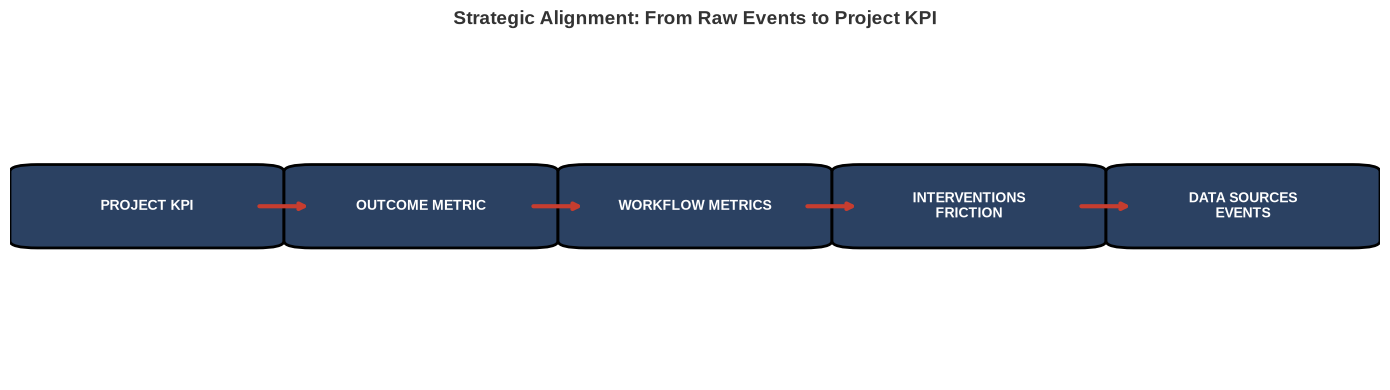


--- Final Project View & Deliverables ---


,Category,Details
0,Core Entities,"Orders (canonical grain), Customers, Restaurants, Drivers, Support Tickets, Interventions"
1,Key Events,"ORDER_CREATED, PICKED_UP, DELIVERED, SUPPORT_OPENED, PRIORITY_DISPATCH, REST_STATUS"
2,Relationships,"Order acts as the central hub (1:1 with Outcomes; 1:N with Actions, Interventions, Tickets)"
3,3-5 Metrics,"Late Delivery Rate, Average Delay Min, Support Interaction Rate, Intervention Rate"
4,KPI Linkage,Late Delivery Rate strictly defines the KPI; Support & Interventions track the cost/friction of missing it
5,Modelling Limitation,Lack of automated prep-completion signals makes it hard to split restaurant-delay from driver-delay



=== CHALLENGE 6 INSIGHTS: STRATEGIC KPI ALIGNMENT ===
1. Which metrics are directly controllable by operations?
   -> Intervention volume and priority dispatch thresholds. Operations cannot directly
      control the weather or traffic, but they CAN control when and how they intervene.

2. Which are outcomes?
   -> Late Delivery Rate (binary) and Average Delay Minutes (continuous). These are the
      final, immutable results of the workflow.

3. Which missing event limits the model most?
   -> Precise driver geolocation pings or accurate 'food ready' timestamps. Without these,
      we cannot definitively distinguish prep-delay in the kitchen from travel-delay on the road.

4. What would you instrument next?
   -> Automated prep-completion signals directly integrated from the restaurant POS systems
      (rather than relying on manual staff taps), which would close the biggest visibility gap.
------------------------------------------------------------------------------------------
F

In [109]:
# --- 1. PREPARE THE DELIVERABLES DATAFRAME ---
deliverables_data = {
    "Category": [
        "Core Entities",
        "Key Events",
        "Relationships",
        "3-5 Metrics",
        "KPI Linkage",
        "Modelling Limitation"
    ],
    "Details": [
        "Orders (canonical grain), Customers, Restaurants, Drivers, Support Tickets, Interventions",
        "ORDER_CREATED, PICKED_UP, DELIVERED, SUPPORT_OPENED, PRIORITY_DISPATCH, REST_STATUS",
        "Order acts as the central hub (1:1 with Outcomes; 1:N with Actions, Interventions, Tickets)",
        "Late Delivery Rate, Average Delay Min, Support Interaction Rate, Intervention Rate",
        "Late Delivery Rate strictly defines the KPI; Support & Interventions track the cost/friction of missing it",
        "Lack of automated prep-completion signals makes it hard to split restaurant-delay from driver-delay"
    ]
}
deliverables_df = pd.DataFrame(deliverables_data)


# --- 2. VISUAL EXPLANATION (FLOWCHART: DATA TO KPI) ---
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Define nodes in the hierarchy
nodes = [
    ("PROJECT KPI", 0.1),
    ("OUTCOME METRIC", 0.3),
    ("WORKFLOW METRICS", 0.5),
    ("INTERVENTIONS / FRICTION", 0.7),
    ("DATA SOURCES / EVENTS", 0.9)
]

# Draw nodes and connecting arrows
for i in range(len(nodes)):
    node_label, x_pos = nodes[i]
    
    # Draw node box
    box = patches.FancyBboxPatch((x_pos - 0.08, 0.4), 0.16, 0.2, boxstyle="round,pad=0.02", 
                                 ec='#000000', fc='#2B4162', lw=2)
    ax.add_patch(box)
    ax.text(x_pos, 0.5, node_label.replace(" / ", "\n"), ha='center', va='center', 
            color='#ffffff', fontweight='bold', fontsize=10)
    
    # Draw arrow to next node
    if i < len(nodes) - 1:
        next_x = nodes[i+1][1]
        ax.annotate('', xy=(next_x - 0.08, 0.5), xytext=(x_pos + 0.08, 0.5),
                    arrowprops=dict(arrowstyle="->", color='#C63D2F', lw=3))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Strategic Alignment: From Raw Events to Project KPI', color='#333333', weight='bold', fontsize=14)

plt.tight_layout()
plt.show()


# --- 3. VISUAL EXPLANATION (DATAFRAME) ---
print("\n--- Final Project View & Deliverables ---")
display(deliverables_df.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))


# --- 4. TEXTUAL EXPLANATION (ANSWERS & INSIGHTS) ---
print("\n" + "="*90)
print("=== CHALLENGE 6 INSIGHTS: STRATEGIC KPI ALIGNMENT ===")
print("="*90)

print("1. Which metrics are directly controllable by operations?")
print("   -> Intervention volume and priority dispatch thresholds. Operations cannot directly")
print("      control the weather or traffic, but they CAN control when and how they intervene.")

print("\n2. Which are outcomes?")
print("   -> Late Delivery Rate (binary) and Average Delay Minutes (continuous). These are the")
print("      final, immutable results of the workflow.")

print("\n3. Which missing event limits the model most?")
print("   -> Precise driver geolocation pings or accurate 'food ready' timestamps. Without these,")
print("      we cannot definitively distinguish prep-delay in the kitchen from travel-delay on the road.")

print("\n4. What would you instrument next?")
print("   -> Automated prep-completion signals directly integrated from the restaurant POS systems")
print("      (rather than relying on manual staff taps), which would close the biggest visibility gap.")

print("-" * 90)
print("FINAL REFLECTION:")
print("A strong solution does not produce the largest schema. It produces the smallest useful model")
print("that explains the workflow and supports the project KPI. By aggregating distributed events into")
print("a single order-level table, we successfully bridged the gap between engineering logs and business strategy.")
print("==========================================================================================")

# Final reflection

A strong solution does not produce the largest schema.

It produces the **smallest useful model that explains the workflow and supports the project KPI**.